NB 2 - EDA and Forecasting

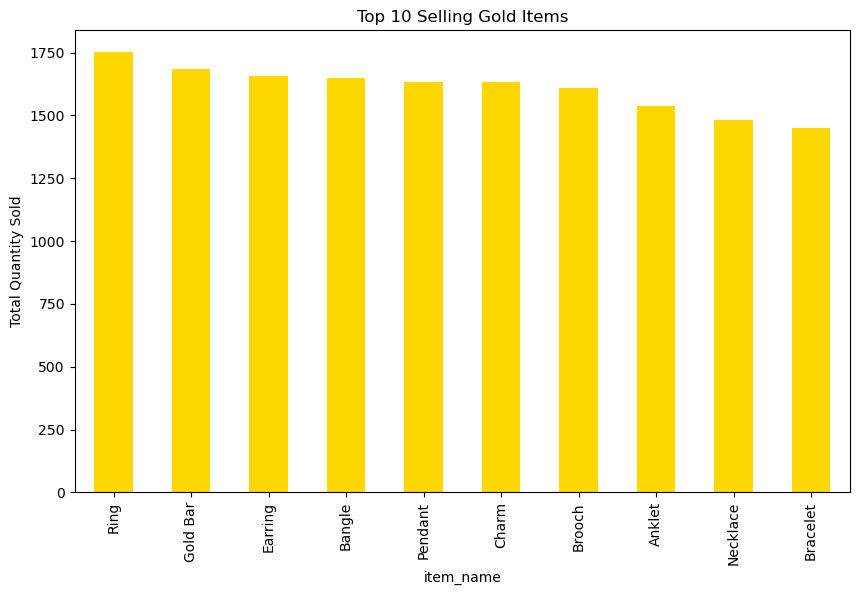

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Projects/12_Inventory_Forecast/data/cleaned_gold_stock_data.csv')


# Top Seller Plot
# Rank items by quantity sold
top_sellers = df.groupby('item_name')['quantity_sold'].sum().sort_values(ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
top_sellers.plot(kind='bar', color='gold')
plt.title('Top 10 Selling Gold Items')
plt.ylabel('Total Quantity Sold')
plt.show()

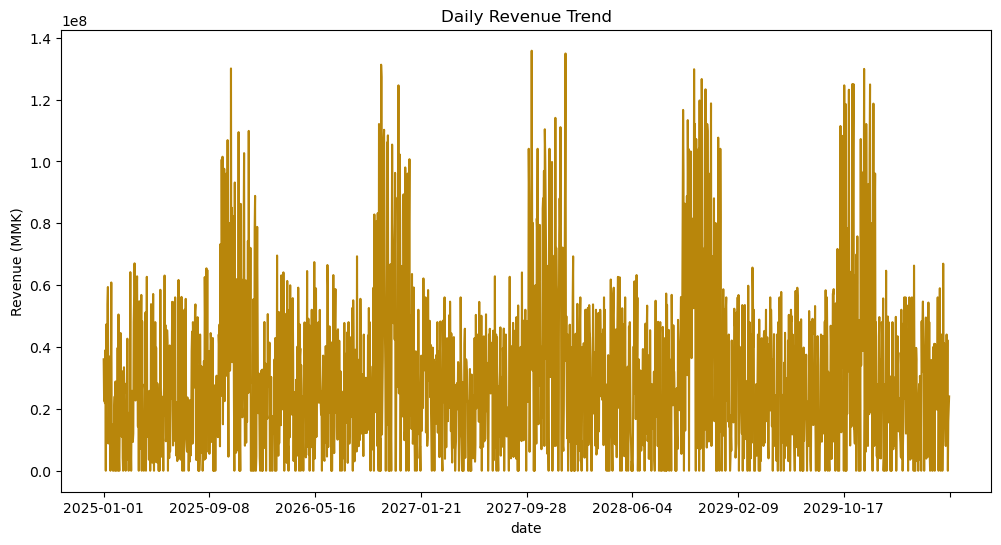

In [2]:
# Revenue changes over time
# Group by date to see revenue trends
daily_revenue = df.groupby('date')['revenue'].sum()

# Visualization
plt.figure(figsize=(12, 6))
daily_revenue.plot(color='darkgoldenrod')
plt.title('Daily Revenue Trend')
plt.ylabel('Revenue (MMK)')
plt.show()

In [3]:
# # Create a summary table for stock
stock_health = df.groupby('item_name')[['quantity_sold', 'stock_left']].sum()
stock_health['status'] = ['Low' if s < 50 else 'Healthy' for s in stock_health['stock_left']]

print(stock_health)

           quantity_sold  stock_left   status
item_name                                    
Anklet              1539       10243  Healthy
Bangle              1648       10053  Healthy
Bracelet            1449        9077  Healthy
Brooch              1609        9480  Healthy
Charm               1633       10472  Healthy
Earring             1657       10744  Healthy
Gold Bar            1683       10678  Healthy
Necklace            1480       10279  Healthy
Pendant             1634       10058  Healthy
Ring                1751       11422  Healthy


## Forecasting 

In [9]:
import sys
print(sys.executable)

c:\Users\shwey\anaconda3\python.exe


In [10]:
import sys
!{sys.executable} -m pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.97-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.97-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----

16:24:19 - cmdstanpy - INFO - Chain [1] start processing
16:24:19 - cmdstanpy - INFO - Chain [1] done processing


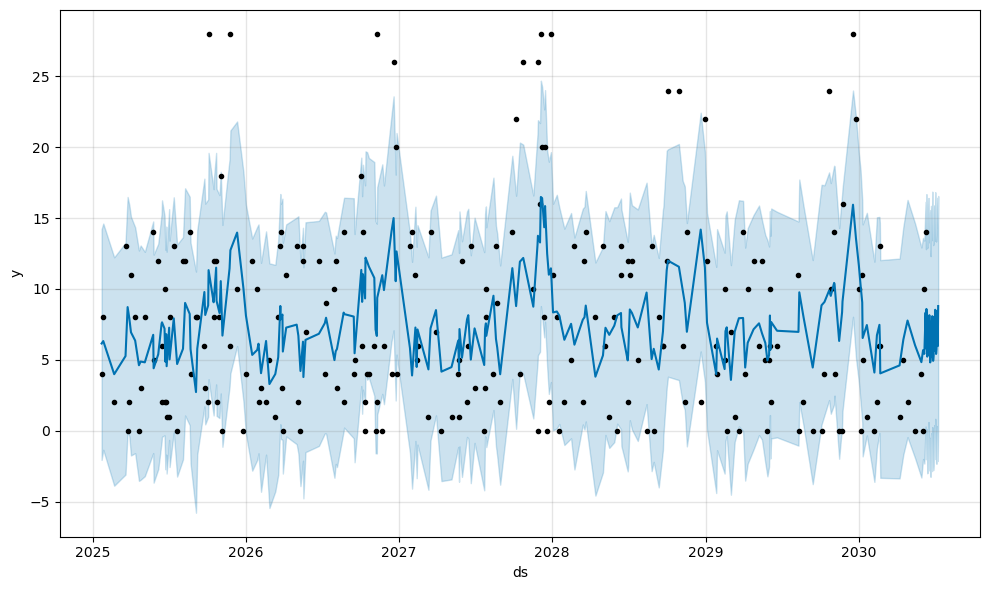

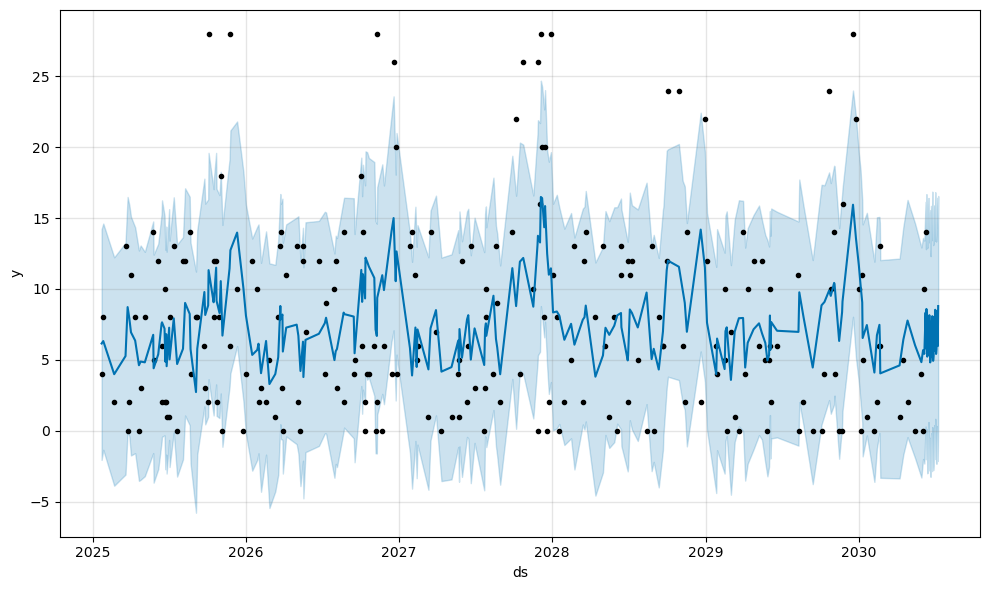

In [11]:
from prophet import Prophet

# Create a dataframe for a specific item (e.g., 'Ring')
ring_data = df[df['item_name'] == 'Ring'][['date', 'quantity_sold']]
ring_data = ring_data.rename(columns={'date': 'ds', 'quantity_sold': 'y'})

# Initialize and train
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(ring_data)

# Predict the next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Visualize the forecast
model.plot(forecast)

In [12]:
# Create forecasting function
def train_and_forecast(item_name, df):
    # 1. Prepare data
    item_df = df[df['item_name'] == item_name][['date', 'quantity_sold']]
    item_df = item_df.rename(columns={'date': 'ds', 'quantity_sold': 'y'})
    
    # 2. Train
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)
    model.fit(item_df)
    
    # 3. Forecast
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    
    return model, forecast

In [13]:
# Save the model
import pickle

# Train for all items and save
items = df['item_name'].unique()

for item in items:
    model, forecast = train_and_forecast(item, df)
    
    # Save the model
    with open(f'{item}_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f"Model for {item} saved!")

16:27:35 - cmdstanpy - INFO - Chain [1] start processing
16:27:35 - cmdstanpy - INFO - Chain [1] done processing
16:27:36 - cmdstanpy - INFO - Chain [1] start processing
16:27:36 - cmdstanpy - INFO - Chain [1] done processing


Model for Anklet saved!


16:27:36 - cmdstanpy - INFO - Chain [1] start processing
16:27:36 - cmdstanpy - INFO - Chain [1] done processing


Model for Bracelet saved!


16:27:36 - cmdstanpy - INFO - Chain [1] start processing
16:27:36 - cmdstanpy - INFO - Chain [1] done processing


...

Model for Necklace saved!


16:27:37 - cmdstanpy - INFO - Chain [1] start processing
16:27:37 - cmdstanpy - INFO - Chain [1] done processing


Model for Pendant saved!
Model for Earring saved!


16:27:37 - cmdstanpy - INFO - Chain [1] start processing
16:27:37 - cmdstanpy - INFO - Chain [1] done processing
16:27:37 - cmdstanpy - INFO - Chain [1] start processing
16:27:38 - cmdstanpy - INFO - Chain [1] done processing


Model for Ring saved!
Model for Brooch saved!
